In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

# Wafer size (13x13 grid = 169 dies)
wafer_size = 13
x_coords = []
y_coords = []
lot_ids = []
defect_types = []
statuses = []

for lot in range(1, 11):  # 10 wafer lots
    for x in range(wafer_size):
        for y in range(wafer_size):
            x_coords.append(x)
            y_coords.append(y)
            lot_ids.append(f"LOT-{lot:02d}")

            # Classify defect pattern
            edge = (x == 0 or x == wafer_size-1 or y == 0 or y == wafer_size-1)
            cluster = (5 <= x <= 7 and 5 <= y <= 7)
            fail_chance = 0.7 if edge else (0.6 if cluster else 0.1)
            failed = np.random.rand() < fail_chance

            if failed:
                if edge:
                    defect_types.append("Edge")
                elif cluster:
                    defect_types.append("Cluster")
                else:
                    defect_types.append("Random")
                statuses.append("FAIL")
            else:
                defect_types.append("None")
                statuses.append("PASS")

df = pd.DataFrame({
    "Lot_ID": lot_ids,
    "X": x_coords,
    "Y": y_coords,
    "Status": statuses,
    "Defect_Type": defect_types
})

print(df.shape)
df.head(10)

(1690, 5)


,Lot_ID,X,Y,Status,Defect_Type
0,LOT-01,0,0,FAIL,Edge
1,LOT-01,0,1,PASS,None
2,LOT-01,0,2,PASS,None
3,LOT-01,0,3,FAIL,Edge
4,LOT-01,0,4,FAIL,Edge
5,LOT-01,0,5,FAIL,Edge
6,LOT-01,0,6,FAIL,Edge
7,LOT-01,0,7,PASS,None
8,LOT-01,0,8,FAIL,Edge
9,LOT-01,0,9,PASS,None


In [4]:
# Yield per lot
yield_summary = df.groupby("Lot_ID").apply(
    lambda x: round((x["Status"] == "PASS").sum() / len(x) * 100, 2)
).reset_index()
yield_summary.columns = ["Lot_ID", "Yield_%"]

print(yield_summary)

   Lot_ID  Yield_%
0  LOT-01    68.64
1  LOT-02    69.82
2  LOT-03    65.09
3  LOT-04    69.82
4  LOT-05    72.78
5  LOT-06    68.05
6  LOT-07    71.60
7  LOT-08    69.23
8  LOT-09    72.78
9  LOT-10    71.60


/tmp/ipykernel_6930/3405031167.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yield_summary = df.groupby("Lot_ID").apply(


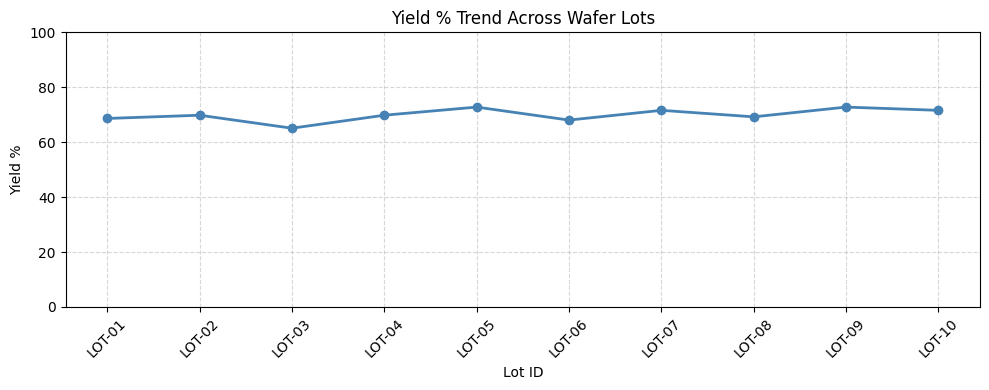

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(yield_summary["Lot_ID"], yield_summary["Yield_%"], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title("Yield % Trend Across Wafer Lots")
plt.ylabel("Yield %")
plt.xlabel("Lot ID")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6930/1182126082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=defect_df, x="Defect_Type", palette="Set2")


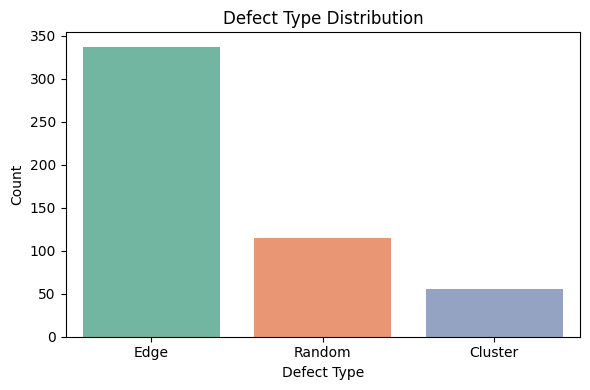

In [6]:
defect_df = df[df["Defect_Type"] != "None"]

plt.figure(figsize=(6, 4))
sns.countplot(data=defect_df, x="Defect_Type", palette="Set2")
plt.title("Defect Type Distribution")
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

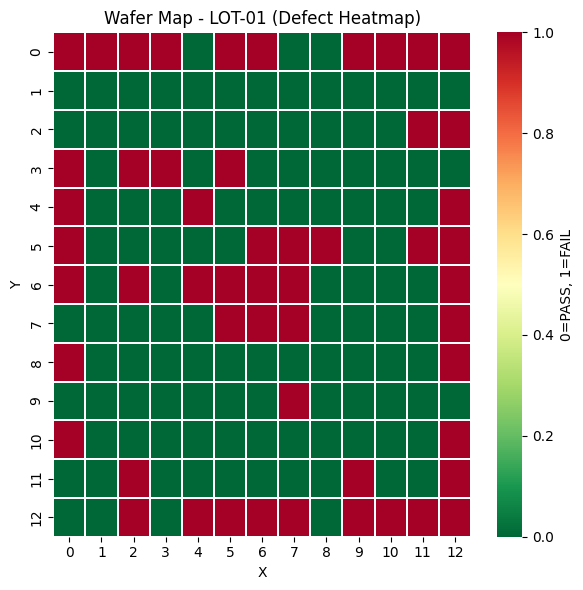

In [7]:
lot1 = df[df["Lot_ID"] == "LOT-01"].copy()
wafer_grid = lot1.pivot(index="Y", columns="X", values="Status")
wafer_grid_num = (wafer_grid == "FAIL").astype(int)

plt.figure(figsize=(6, 6))
sns.heatmap(wafer_grid_num, cmap="RdYlGn_r", linewidths=0.3,
            cbar_kws={"label": "0=PASS, 1=FAIL"})
plt.title("Wafer Map - LOT-01 (Defect Heatmap)")
plt.tight_layout()
plt.show()

In [8]:
from google.colab import files

with pd.ExcelWriter("wafer_yield_report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Raw Data", index=False)
    yield_summary.to_excel(writer, sheet_name="Yield Summary", index=False)

files.download("wafer_yield_report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>